# NP1 - L2

## Parte teórica (5 pontos cada)

Classifique as afirmações em Verdadeiro ou Falso, justifique as afirmativas falsas

1 - As imagens matricias são mais usadas em logos, pois apresentam serrilhamento quando são ampliadas

In [13]:
print("Falso. Imagens matriciais não são utilizadas em logos de empresas,\npor justamente apresentarem serrilhamento. Perdendo qualidade")

Falso. Imagens matriciais não são utilizadas em logos de empresas,
por justamente apresentarem serrilhamento. Perdendo qualidade


2 - O padrão de cores CMY é utilizado em impressões, enquanto o RGB é usado em displays.

In [14]:
print("Verdadeiro. CMY é mais usado em impressão por ser um modelo com absorção de luz, enquanto RGB é aditivo e mais usado em telas (pois elas já emitem a luz)")

Verdadeiro. CMY é mais usado em impressão por ser um modelo com absorção de luz, enquanto RGB é aditivo e mais usado em telas (pois elas já emitem a luz)


3 - O código abaixo é usado para importar uma imagem e retirar o terceiro campo de cor (Blue, ou azul, do RGB)

```imagem = np.array(Image.open('Clara.png'))[:, :, :3]```

4 -  A lógica OR aplicada em uma imagem detecta os pixels que não mudaram de valor

In [15]:
print("Falso. Aplicar OR entre duas imagens retorna os pixels que são 1 em pelo menos uma das imagens, ou seja aqueles que mudaram em pelo menos uma das imagens.")

Falso. Aplicar OR entre duas imagens retorna os pixels que são 1 em pelo menos uma das imagens, ou seja aqueles que mudaram em pelo menos uma das imagens.


5 - O padrão de cores CMY é o mais próximo da visão humana.

In [16]:
print("Verdadeiro. O padrão CMY é o mais próximo do que o olho humano percebe,\npois é baseado na absorção de luz, o que o nosso olho faz(o contrário do RGB)")

Verdadeiro. O padrão CMY é o mais próximo do que o olho humano percebe,
pois é baseado na absorção de luz, o que o nosso olho faz(o contrário do RGB)


# Parte prática (5 pontos cada, exceto a questão 11 que vale 10)

## Material de apoio

### Importações

```python
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
```

### Manipulação de imagens

```python
img = Image.open('nome.extensão')
img = np.array(Image.open('nome.extensão'))
img = img[:, :, :3]
img_pil = Image.fromarray(img_np)
img.save('nome.png')
Image.fromarray(img).save('nome_arquivo.extensao')
(l,c,p) = img.shape
```

### Greyscale

#### Algoritmo genérico, substituir o método escolhido
```python
img_avg = np.zeros(shape=(l, c), dtype=np.uint8)
for i in range(l):
    for j in range(c):
        r = float(img_np[i, j, 0])
        g = float(img_np[i, j, 1])
        b = float(img_np[i, j, 2])
        
        img_avg[i, j] = (aplicar método)
```

#### Métodos: 


Lightness: $\frac{max(R,G,B)+min(R,G,B)}{2}$


Average: $\frac{R+G+B}{3}$


Luminosity: $0.2126 \cdot R + 0.7152 \cdot G + 0.0722 \cdot B$


RGB para CMY:
### <font color="red">R</font><font color="green">G</font><font color="blue">B</font> para <font color="cyan">C</font><font color="magenta">M</font><font color="yellow">Y</font>
$$\begin{pmatrix}
    C \\ M \\ Y
\end{pmatrix} = \begin{pmatrix}
    1 \\ 1 \\ 1
\end{pmatrix} - \begin{pmatrix}
    R \\ G \\ B
\end{pmatrix} e \begin{pmatrix}
    R \\ G \\ B
\end{pmatrix} = \begin{pmatrix}
    1 \\ 1 \\ 1
\end{pmatrix} - \begin{pmatrix}
    C \\ M \\ Y
\end{pmatrix}$$
* **<font color="red">R</font>** + **<font color="cyan">C</font>** = 1 (ou 255);
* **<font color="green">G</font>** + **<font color="magenta">M</font>** = 1;
* **<font color="blue">B</font>** + **<font color="yellow">Y</font>** = 1.


Interpolação Bilinear:
Seja $I$ a imagem de entrada $L_{entrada}×C_{entrada}$ e $J$ a imagem de saída $L_{saída}×C_{saída}.$

Seja $s_L = L_{entrada}/L_{saída}$ e $s_C = C_{entrada}/C_{saída}.$

Seja $l_f = l \cdot s_L$ para $r=0,\ldots,R_{saída}-1$ e $c_f = c \cdot s_C$ para $c=0,\ldots,C_{saída}-1.$

Seja $r_0 = \lfloor{l_f}\rfloor$ e $c=\lfloor{c_f}\rfloor.$

Seja $\Delta_l = l_f - l_0$ e $\Delta_c = c_f - c_0.$

Então $J(l, c)$
$$=I(l_0, c_0) \cdot (1-\Delta_l) \cdot (1-\Delta_c)$$
$$+I(l_0+1, c_0) \cdot \Delta_l \cdot (1-\Delta_c)$$
$$+I(l_0, c_0+1) \cdot (1-\Delta_l) \cdot \Delta_c$$
$$+I(l_0+1, c_0+1) \cdot \Delta_l \cdot \Delta_c.$$

### Escalonamento com nearest neighbor

```python
ls, cs = l * sy, c * sx
mario_nn = np.zeros(shape=(ls, cs, p), dtype=np.uint8)

for i in range(ls):
    for j in range(cs):
        new_y = int(np.floor(i * (l / ls)))
        new_x = int(np.floor(j * (c / cs)))
        
        mario_nn[i, j] = mario[new_y, new_x]
```
### Escalonamento clássico
```python
scale_x, scale_y = 2, 2
mario_scale = np.zeros(shape=(l * scale_y, c * scale_x, p), dtype=np.uint8)
for i in range(l):
    for j in range(c):
        new_x = np.round(j * scale_x)
        new_y = np.round(i * scale_y)
        mario_scale[new_y, new_x] = mario[i, j]

plt.imshow(mario_scale)
Image.fromarray(mario_scale).save('mario_scale.png')
```

### Cisalhamento

```python
img_shear = np.zeros((int(l * (1.1 + cy)), int(c * (1.1 + cx)), p), dtype=np.uint8)
for i in range(l):
    for j in range(c):
        new_x = int(j + cx * i)
        new_y = int(cy * j + i)
        
        img_shear[new_y, new_x] = img[i, j]
```

### Imagem grayscale para imagem binária de 3 canais

```python
bin = np.zeros(shape=(l,c,3),dtype=np.uint8)
    
for i in range(l):
    for j in range(c):
        if img[i,j] > thresh: 
            bin[i,j,:] = 255 
        else: 
            bin[i,j,:] = 0

```
### Blending com escala genérica

```python
imagem_blending = (C * img_1) + ((1 - C) * img_2)
imagem_blending = imagem_blending.astype(np.uint8)
```

### Histograma
```python
def histogram_gray(img):
    (l, c) = img.shape
    histogram = np.zeros(256, dtype=np.int32)

    for i in range(l):
        for j in range(c):
            intensity = img[i, j]
            histogram[intensity] += 1
            
    return histogram

def show_histogram_gray(img):
    histogram = histogram_gray(img)
    plt.figure(figsize=(16, 16))
    plt.subplot(2, 1, 1)
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.subplot(2, 1, 2)
    plt.bar(range(256), histogram)

def show_histogram(img):
    histogram_r = histogram_gray(img[:, :, 0])
    histogram_g = histogram_gray(img[:, :, 1])
    histogram_b = histogram_gray(img[:, :, 2])
    
    plt.figure(figsize=(16, 16))
    plt.subplot(2, 1, 1)
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.subplot(2, 1, 2)
    plt.bar(range(256), histogram_r, color='red')
    plt.bar(range(256), histogram_g, color='green')
    plt.bar(range(256), histogram_b, color='blue')

```
### Espelhamento
```python
refl = np.zeros(shape=example.shape, dtype=np.uint8)
for i in range(l):
    for j in range(c):
        new_x = -j
        new_y = i
        refl[new_y, new_x] = example[i, j]

plt.imshow(refl)
```


No outro eixo

```python
refl = np.zeros(shape=example.shape, dtype=np.uint8)
refl[::-1, ::1] = example
plt.imshow(refl)
```

### Detecção de bordas 
```python
abs_tg_c = np.abs(np.diff(museum.astype(np.float64), axis=0, append=255))

abs_tg_l = np.abs(np.diff(museum.astype(np.float64), axis=1, append=255))

abs_tg = np.sqrt(abs_tg_c ** 2 + abs_tg_l ** 2)

threshold = 16
museum_border = np.zeros(shape=(l, c), dtype=np.uint8)
museum_border[abs_tg > threshold] = 255
```

### Operações lógicas
NOT:
```python
bin1_not = np.bitwise_not(bin1)
bin2_not = np.invert(bin2)
```
AND:
```python
bin_and = np.bitwise_and(bin1, bin2)
```
OR: 
```python
bin_or = np.bitwise_or(bin1, bin2)
```
XOR 
```python
bin_xor = np.bitwise_xor(bin1, bin2)
```

**1 - (5 pontos)** Importe as bibliotecas que serão usadas

In [17]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt 

**2 - (5 pontos)** Abra as imagens techno.jpg, Shrine.jpg e Ninja.jpg, retire o canal alpha se necessário, exiba essas imagens e mostre o formato de cada uma

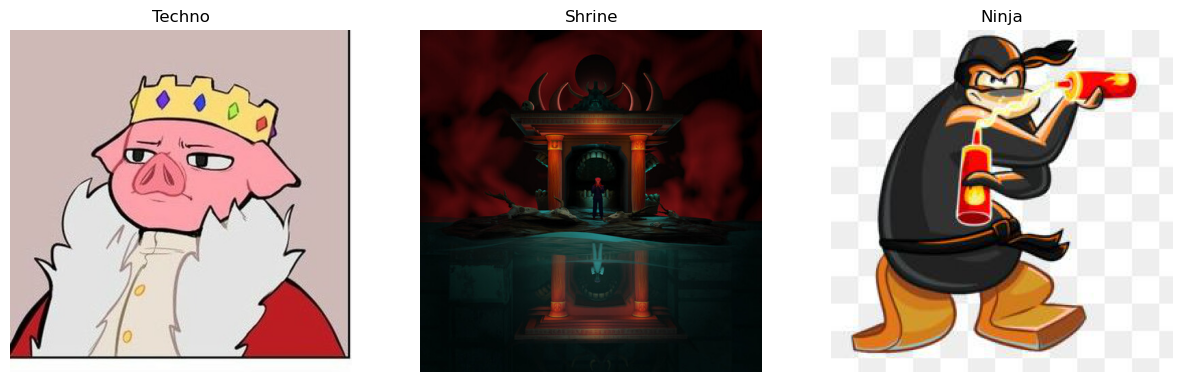

Dimensões das imagens

Ninja: 250x250 pixels, 3 channels
Techno: 500x500 pixels, 3 channels
Shrine: 500x500 pixels, 3 channels


In [18]:
techno = np.array(Image.open("techno.jpg"))[:,:,:3]
shrine = np.array(Image.open("Shrine.jpg"))[:,:,:3]
ninja = np.array(Image.open("Ninja.jpg"))[:,:,:3]

def plot_images(images, titles):
    plt.figure(figsize=(15, 5))
    # Obs: enumerate e zip servem para iterar sobre as imagens e seus títulos simultaneamente 
    # e para obter o índice de cada imagem para posicioná-la corretamente no subplot
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(img)
        plt.title(title)
        plt.axis('off')
    plt.show()

plot_images([techno, shrine, ninja], ['Techno', 'Shrine', 'Ninja'])


lt, ct, pt = techno.shape
ls, cs, ps = shrine.shape
ln, cn, pn = ninja.shape

print(f"Dimensões das imagens\n")
print(f"Ninja: {ln}x{cn} pixels, {pn} channels")
print(f"Techno: {lt}x{ct} pixels, {pt} channels")
print(f"Shrine: {ls}x{cs} pixels, {ps} channels")


**3 - (5 pontos)** Crie uma função que realize o escalonamento de uma imagem para que Ninja e Techno fiquem do mesmo tamanho. Utilize o método de sua preferência e mostre o resultado

Dimensões da imagem ninja escalada: 500x500 pixels, 3 channels


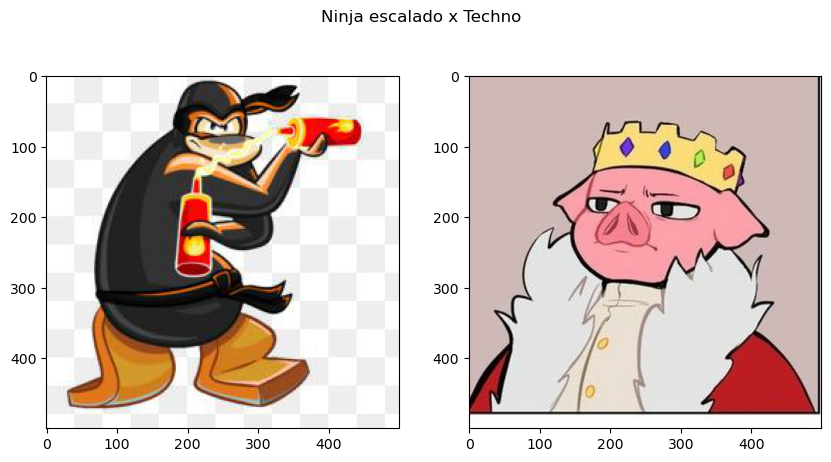

In [19]:
# função recebe a imagem a ser escalonada e a imagem de referencia
def scale_image(img_to_scaled, img):
    (l, c, p) = img_to_scaled.shape
    (lt, ct, p) = img.shape
    img_scaled = np.zeros(shape=(lt, ct, p), dtype=np.uint8)

    for i in range(lt):
        for j in range(ct):
            x = int(j * c / ct) # calcula a posição x correspondente na imagem original
            y = int(i * l / lt) # calcula a posição y correspondente na imagem original

            img_scaled[i,j] = img_to_scaled[y,x]

    return img_scaled


ninja_scale = scale_image(ninja, techno)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(ninja_scale)
plt.subplot(1, 2, 2)
plt.imshow(techno)
plt.suptitle("Ninja escalado x Techno")

print(f"Dimensões da imagem ninja escalada: {ninja_scale.shape[0]}x{ninja_scale.shape[1]} pixels, {ninja_scale.shape[2]} channels")


**4 - (10 pontos)** Aplique a espelhamento Y à imagem techno. Mostre o resultado

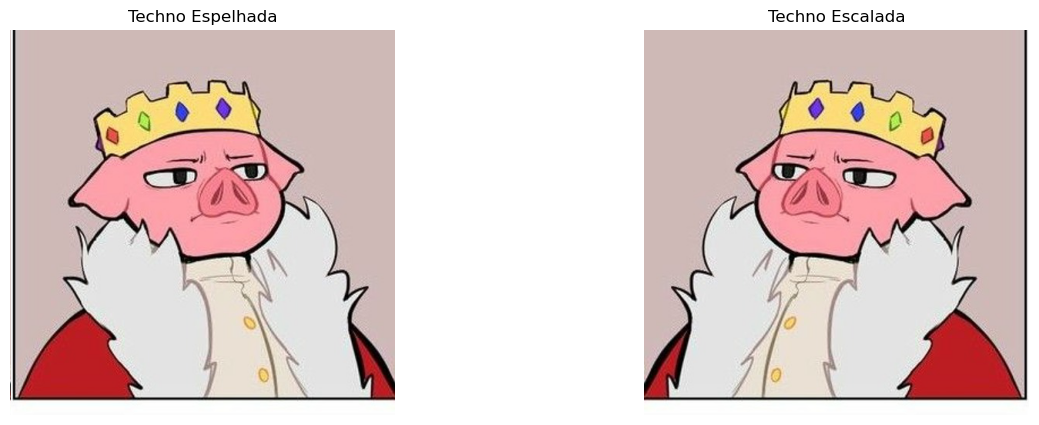

In [20]:
# função para espelhar a imagem (espelhamento em relação ao eixo Y inverte X)
def espelhamento(img):
    (l, c, p) = img.shape
    img_espelhada = np.zeros(shape=(l, c, p), dtype=np.uint8)

    for i in range(l):
        for j in range(c):
            x = -j
            y = i

            img_espelhada[y,x] = img[i,j]
            
    return img_espelhada

techno_espelhada = espelhamento(techno)
plot_images([techno_espelhada, techno], ['Techno Espelhada', 'Techno Escalada'])


**5 - (10 pontos)** Aplique a técnica Greyscale a imagem resultante da questão 4. Mostre o resultado

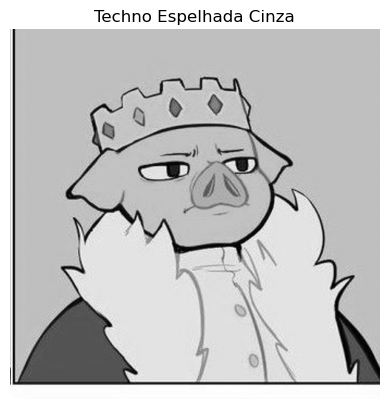

In [21]:
l, c, p = techno_espelhada.shape

techno_espelhada_gray = np.zeros(shape=(l, c), dtype=np.uint8)

for i in range(l):
    for j in range(c):
        r = float(techno_espelhada[i, j, 0])
        g = float(techno_espelhada[i, j, 1])
        b = float(techno_espelhada[i, j, 2])
        
        techno_espelhada_gray[i, j] = int(r + g + b) / 3


plt.imshow(techno_espelhada_gray, cmap="gray")
plt.title("Techno Espelhada Cinza")
plt.axis('off')
plt.show()

**6 - (10 pontos)** Crie uma função para transformar imagem RGB em CMY. Aplique a imagem da **questão 4**. Mostre o resultado

(np.float64(-0.5), np.float64(499.5), np.float64(499.5), np.float64(-0.5))

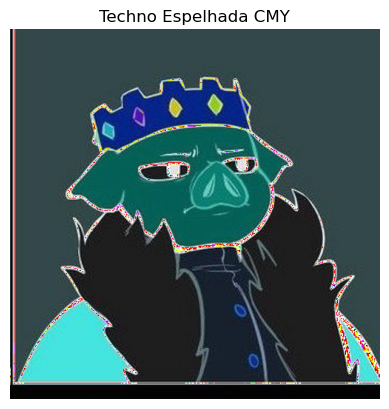

In [22]:
def rgb_to_cmy(img):
    # CMY é o inverso de RGB
    (l, c, p) = img.shape
    cmy = np.zeros(shape=(l, c, p), dtype=float)

    cmy = 1 - img

    return cmy

techno_espelhada_cmy = rgb_to_cmy(techno_espelhada)
plt.imshow(techno_espelhada_cmy)
plt.title("Techno Espelhada CMY")
plt.grid(False)
plt.axis('off')


**7 - (10 pontos)** Aplique a operação XOR com as imagens resultantes da questões 4 e 6. Mostre o resultado

dimensão do resultado do XOR: (500, 500, 3)


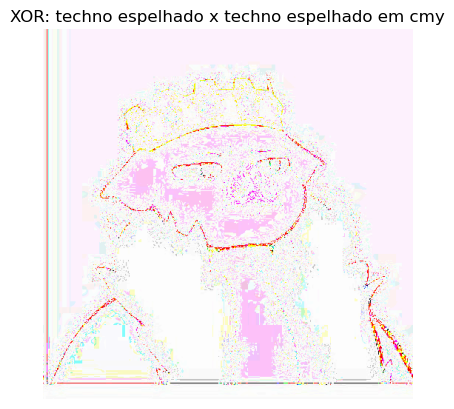

In [23]:
resut_xor = np.bitwise_xor(techno_espelhada, techno_espelhada_cmy)

print("dimensão do resultado do XOR:", resut_xor.shape)

plt.imshow(resut_xor)
plt.title("XOR: techno espelhado x techno espelhado em cmy")
plt.grid(False)
plt.axis('off')
plt.show()

**8 - (10 pontos)** Aplique o escalonamento com nearest neighbor com fator sx = 1.5 e sy = 1.2 na imagem resultante na questão anterior, após isso salve a imagem no disco com o nome "resultado.jpg"

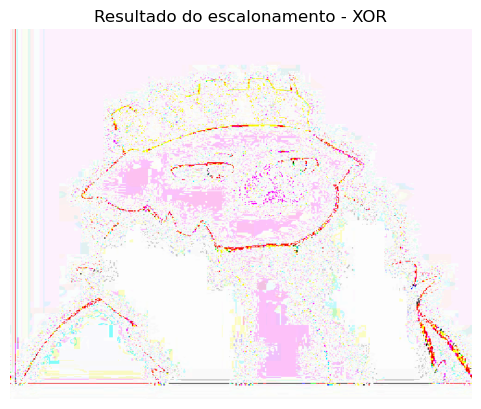

In [24]:
# Taxas de conversão
sx = 1.5
sy = 1.2

l, c, p = resut_xor.shape

ls = int(l * sy) # pegando o inteiro por resultar em um valor quebrado
cs = int(c*sx) # mesma coisa do acima

resultado1 = np.zeros(shape=(ls, cs, p), dtype=np.uint8)

for i in range(ls):
    for j in range(cs):
        new_y = int(np.floor(i * (l / ls)))
        new_x = int(np.floor(j * (c / cs)))
        
        resultado1[i, j] = resut_xor[new_y, new_x]

plt.imshow(resultado1)
plt.axis('off')
plt.title("Resultado do escalonamento - XOR")
plt.show()

Image.fromarray(resultado1).save("resultado1.png")



**9 - (10 pontos)** Apresente o histograma da imagem da questão anterior. Mostre o resultado e explique o que pode ser deduzido a partir dele.

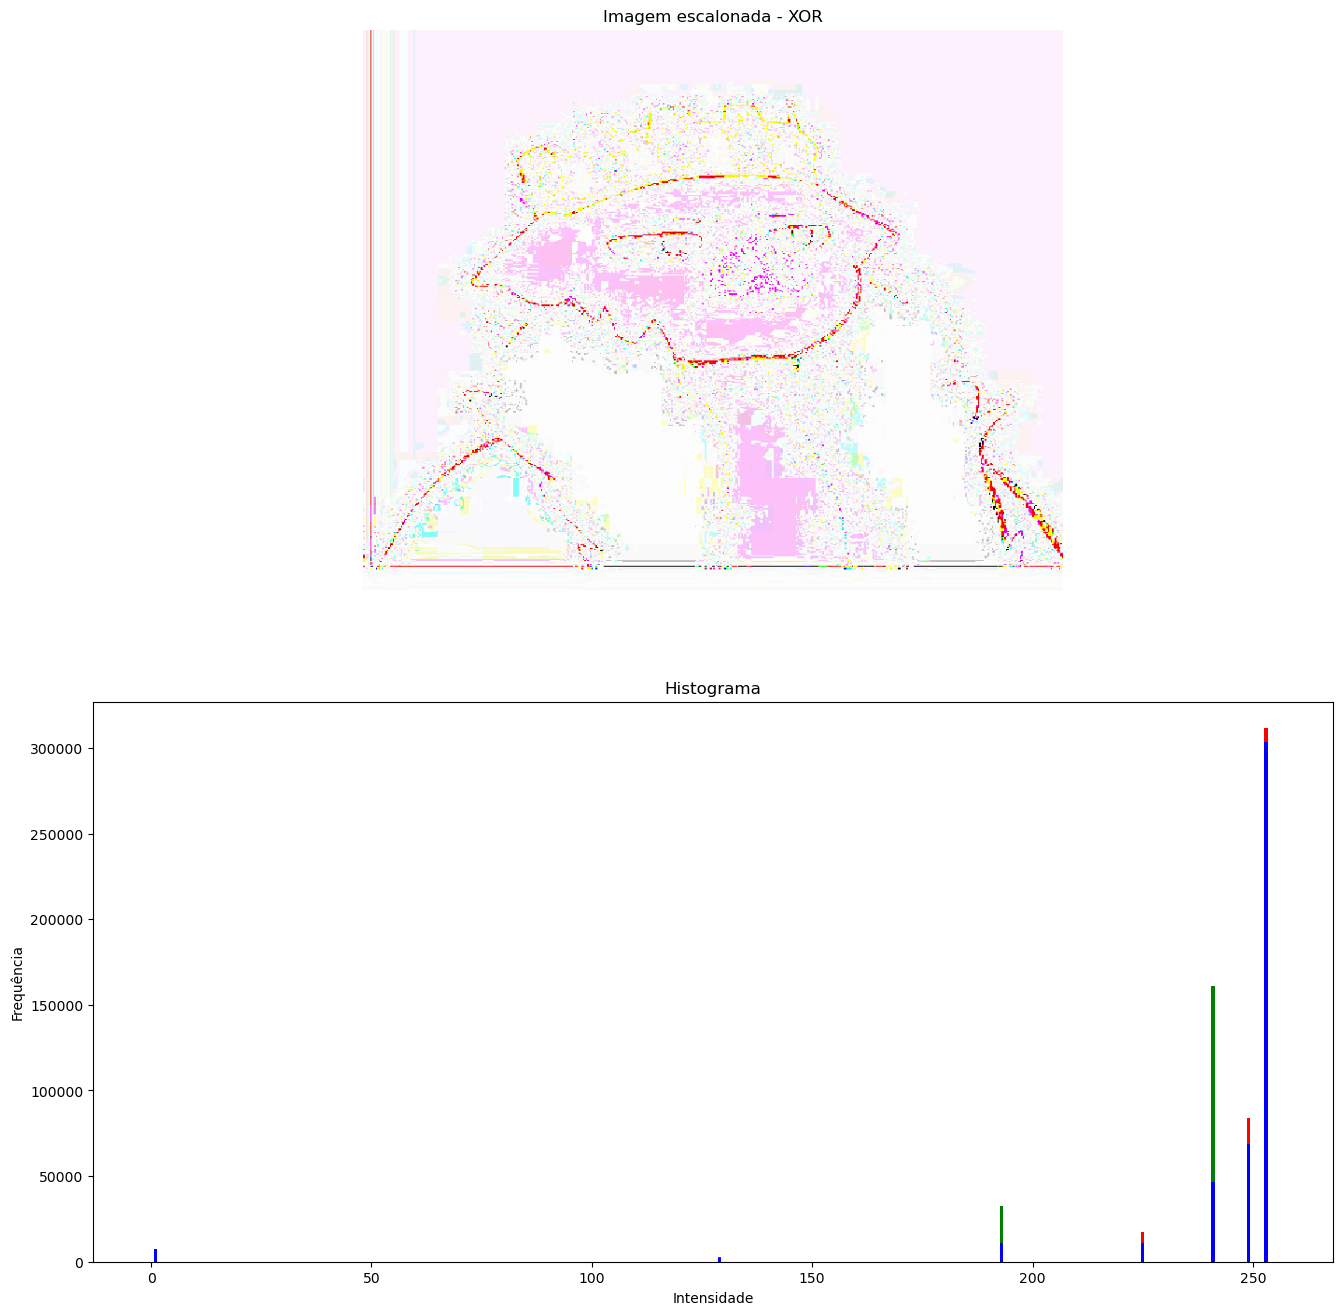

O resultado do histograma mostra que a maioria dos pixels da imagem resultado1 apresentam em maior quantidade nas frequênciaspróximas a 255 (no casom, para as cores RGB), o que indica que a imagem é bem clara, porém com alguns pixels coloridos 


In [25]:
def histogram_gray(image):
    hist = np.zeros(256, dtype=np.int32)
    (l,c) = image.shape

    # cada posição do histograma é a quantidade de pixels com aquela intensidade (a de image[i, j])
    for i in range(l):
        for j in range(c):
            intensidade = image[i, j] # intensidade do pixel (0 a 255)
            hist[intensidade] += 1
    return hist

def show_histogram_gray(image, title):
    hist = histogram_gray(image)

    # plotando a imagem e o histograma ambos com titulo
    plt.figure(figsize=(16, 16))
    plt.subplot(2, 1, 1)
    plt.imshow(image, cmap='gray', vmin=0, vmax=255)
    plt.title(title)
    plt.axis('off')  # remover os eixos da imagem

    plt.subplot(2, 1, 2)
    plt.bar(range(256), hist)
    plt.title('Histograma')
    plt.xlabel('Intensidade')
    plt.ylabel('Frequência')
    plt.show()


def show_histogram(img, title):
    # calculando o histograma para cada canal de cor (R, G, B)
    histogram_r = histogram_gray(img[:, :, 0])
    histogram_g = histogram_gray(img[:, :, 1])
    histogram_b = histogram_gray(img[:, :, 2])

    # plotando a imagem e o histograma ambos com titulo
    plt.figure(figsize=(16, 16))
    plt.subplot(2, 1, 1)
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.title(title)
    plt.axis('off')  # remover os eixos da imagem

    plt.subplot(2, 1, 2)
    plt.bar(range(256), histogram_r, color='red') # histograma do canal vermelho
    plt.bar(range(256), histogram_g, color='green') # histograma do canal verde
    plt.bar(range(256), histogram_b, color='blue')  # histograma do canal azul
    plt.title('Histograma')
    plt.xlabel('Intensidade')
    plt.ylabel('Frequência')
    plt.show() 


show_histogram(resultado1, "Imagem escalonada - XOR")
print("O resultado do histograma mostra que a maioria dos pixels da imagem resultado1 apresentam em maior quantidade nas frequências" \
"próximas a 255 (no casom, para as cores RGB), o que indica que a imagem é bem clara, porém com alguns pixels coloridos ")

# Lembre de entregar tudo como um arquivo ZIP, com o arquivo resultado e seu notebook, NOMEADO COMO: "C09 - LX - SEU NOME COMPLETO"